In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from astropy.table import Table
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
cat = Table.read("lycan_small_cat_v2.fits")
spec = np.load("spectra_new_v2.npy")
cont = np.load("continum_v2.npy")

print(cat)
print("Columnas:", cat.colnames)
print("Continuum shape:", cont.shape)

     TARGETID             Z                  RA                 DEC            RSNR   PROGRAM SURVEY   FLUX_R  
----------------- ------------------ ------------------ ------------------- --------- ------- ------ ----------
39627917549896110 2.1932306549579392 3.2852438433390962   5.408003282780634  8.923307    dark   main   7.868383
39632961187873048  2.338182270630542 201.69553524689513  33.969364061938506 1.8647346    dark   main  1.1061417
39628359340131324  2.175913696417826  337.6124337155897   24.27043834050778 3.3887188    dark   main  2.4008994
39627781268573278 2.7136479150244046 153.87988269964285  -0.284166736018816 17.251913    dark   main  21.327236
39628053004948614 2.4043632422473817 236.15754039421245  10.921361157892035 1.5811208    dark   main  1.7523378
39627539492110579 2.8345350550604174  73.88571439778211 -10.240072402858951 1.7643958    dark   main  1.0831243
39627913682748959  2.574049589857051 132.19330451249238   5.190549468522186 2.7091944    dark   main  1.

In [4]:
Z = np.array(cat["Z"]).astype("float32")
FLUX_R = np.array(cat["FLUX_R"]).astype("float32")

X = np.vstack([Z, FLUX_R]).T.astype("float32")
Y = np.array(cont).astype("float32")

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("NaN en X:", np.isnan(X).sum())
print("NaN en Y:", np.isnan(Y).sum())
print("Inf en X:", np.isinf(X).sum())
print("Inf en Y:", np.isinf(Y).sum())

X shape: (200000, 2)
Y shape: (200000, 699)
NaN en X: 0
NaN en Y: 2097
Inf en X: 0
Inf en Y: 0


In [5]:
mask = (
    np.isfinite(X).all(axis=1)
    & np.isfinite(Y).all(axis=1)
)

print("Filas originales:", X.shape[0])
print("Filas válidas:", mask.sum())
print("Filas eliminadas:", X.shape[0] - mask.sum())

X = X[mask]
Y = Y[mask]

print("Nuevo X shape:", X.shape)
print("Nuevo Y shape:", Y.shape)

Filas originales: 200000
Filas válidas: 199997
Filas eliminadas: 3
Nuevo X shape: (199997, 2)
Nuevo Y shape: (199997, 699)


In [6]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)
print("Y_test:", Y_test.shape)

X_train: (139997, 2)
X_val: (30000, 2)
X_test: (30000, 2)
Y_train: (139997, 699)
Y_val: (30000, 699)
Y_test: (30000, 699)


In [7]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train).astype("float32")
X_val_scaled = scaler_X.transform(X_val).astype("float32")
X_test_scaled = scaler_X.transform(X_test).astype("float32")

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (139997, 2)
X_val_scaled: (30000, 2)
X_test_scaled: (30000, 2)


In [8]:
num_entradas = X_train_scaled.shape[1]
num_puntos = Y_train.shape[1]

model_cont = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(num_entradas,)),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(256, activation="relu"),

    tf.keras.layers.Dense(num_puntos, activation="linear")
])

model_cont.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model_cont.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 699)                 │         179,643 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 221,179 (863.98 KB)

 Trainable params: 221,179 (863.98 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
callback_cont = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_cont = model_cont.fit(
    X_train_scaled,
    Y_train,
    validation_data=(X_val_scaled, Y_val),
    epochs=50,
    batch_size=32,
    callbacks=[callback_cont]
)

Epoch 1/50
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 13.0667 - mae: 1.7310 - val_loss: 11.2176 - val_mae: 1.6730
Epoch 2/50
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 12.9845 - mae: 1.7331 - val_loss: 11.2208 - val_mae: 1.6303
Epoch 3/50
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - loss: 12.9761 - mae: 1.7338 - val_loss: 11.2547 - val_mae: 1.7877
Epoch 4/50
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 12.9711 - mae: 1.7347 - val_loss: 11.2583 - val_mae: 1.5886
Epoch 5/50
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 12.9708 - mae: 1.7337 - val_loss: 11.2797 - val_mae: 1.8198
Epoch 6/50
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - loss: 12.9715 - mae: 1.7347 - val_loss: 11.2135 - val_mae: 1.7294
Epoch 7/50
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - loss: 12.9689 - mae: 1.7343 - val_loss: 11.2133 - val_mae: 1.7281
Epoch 8/50
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - loss: 12.9710 - mae: 1.7347 - val_loss: 11.2044 - val_mae: 1.6948
Epoch 9/50
4375/

In [10]:
Y_pred_train = model_cont.predict(X_train_scaled, batch_size=1024)
Y_pred_val = model_cont.predict(X_val_scaled, batch_size=1024)
Y_pred_test = model_cont.predict(X_test_scaled, batch_size=1024)

print("Y_pred_train:", Y_pred_train.shape)
print("Y_pred_val:", Y_pred_val.shape)
print("Y_pred_test:", Y_pred_test.shape)

137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Y_pred_train: (139997, 699)
Y_pred_val: (30000, 699)
Y_pred_test: (30000, 699)


In [11]:
def calcular_factor_optimo(Y_real, Y_pred, eps=1e-8):
    numerador = np.sum(Y_real * Y_pred, axis=1)
    denominador = np.sum(Y_pred**2, axis=1) + eps
    A_opt = numerador / denominador
    return A_opt.astype("float32")

In [12]:
A_opt_train = calcular_factor_optimo(Y_train, Y_pred_train)
A_opt_val = calcular_factor_optimo(Y_val, Y_pred_val)
A_opt_test = calcular_factor_optimo(Y_test, Y_pred_test)

print("A_opt_train shape:", A_opt_train.shape)
print("A_opt_val shape:", A_opt_val.shape)
print("A_opt_test shape:", A_opt_test.shape)



A_opt_train shape: (139997,)
A_opt_val shape: (30000,)
A_opt_test shape: (30000,)
Percentiles A_opt_train:
[-0.2734921   0.10512528  0.15640757  0.53220016  3.35504494  7.57898781
 74.85850525]
Percentiles A_opt_val:
[-0.1195524   0.10806426  0.15802173  0.53195652  3.34895588  7.28176583
 34.79867935]


In [13]:
Y_pred_val_opt = A_opt_val[:, None] * Y_pred_val
Y_pred_test_opt = A_opt_test[:, None] * Y_pred_test

mae_val_original = np.mean(np.abs(Y_val - Y_pred_val))
mae_val_opt = np.mean(np.abs(Y_val - Y_pred_val_opt))

mae_test_original = np.mean(np.abs(Y_test - Y_pred_test))
mae_test_opt = np.mean(np.abs(Y_test - Y_pred_test_opt))

print("VALIDACIÓN")
print("MAE original:", mae_val_original)
print("MAE con A_opt ideal:", mae_val_opt)
print("Mejora ideal:", mae_val_original / mae_val_opt)

print("\nPRUEBA")
print("MAE original:", mae_test_original)
print("MAE con A_opt ideal:", mae_test_opt)
print("Mejora ideal:", mae_test_original / mae_test_opt)

VALIDACIÓN
MAE original: 1.6866888
MAE con A_opt ideal: 0.19054592
Mejora ideal: 8.851875

PRUEBA
MAE original: 1.6886162
MAE con A_opt ideal: 0.19163428
Mejora ideal: 8.81166


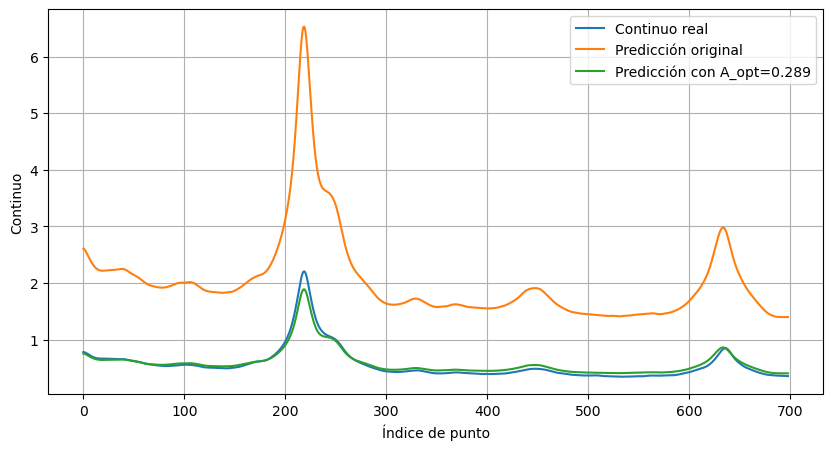

In [14]:
i = 10

y_real = Y_val[i]
y_pred = Y_pred_val[i]
A = A_opt_val[i]
y_pred_opt = A * y_pred

plt.figure(figsize=(10, 5))
plt.plot(y_real, label="Continuo real")
plt.plot(y_pred, label="Predicción original")
plt.plot(y_pred_opt, label=f"Predicción con A_opt={A:.3f}")

plt.xlabel("Índice de punto")
plt.ylabel("Continuo")
plt.legend()
plt.grid()
plt.show()

In [15]:
mask_A_train = np.isfinite(A_opt_train) & (A_opt_train > 0)
mask_A_val = np.isfinite(A_opt_val) & (A_opt_val > 0)
mask_A_test = np.isfinite(A_opt_test) & (A_opt_test > 0)

X_train_A = X_train_scaled[mask_A_train]
X_val_A = X_val_scaled[mask_A_val]
X_test_A = X_test_scaled[mask_A_test]

A_train = A_opt_train[mask_A_train]
A_val = A_opt_val[mask_A_val]
A_test = A_opt_test[mask_A_test]

log_A_train = np.log10(A_train).reshape(-1, 1).astype("float32")
log_A_val = np.log10(A_val).reshape(-1, 1).astype("float32")
log_A_test = np.log10(A_test).reshape(-1, 1).astype("float32")

print("X_train_A:", X_train_A.shape)
print("X_val_A:", X_val_A.shape)
print("X_test_A:", X_test_A.shape)

print("log_A_train:", log_A_train.shape)
print("log_A_val:", log_A_val.shape)
print("log_A_test:", log_A_test.shape)

X_train_A: (139979, 2)
X_val_A: (29993, 2)
X_test_A: (29991, 2)
log_A_train: (139979, 1)
log_A_val: (29993, 1)
log_A_test: (29991, 1)


In [16]:
scaler_A = StandardScaler()

log_A_train_scaled = scaler_A.fit_transform(log_A_train).astype("float32")
log_A_val_scaled = scaler_A.transform(log_A_val).astype("float32")
log_A_test_scaled = scaler_A.transform(log_A_test).astype("float32")

print("Media log_A_train_scaled:", np.mean(log_A_train_scaled))
print("Std log_A_train_scaled:", np.std(log_A_train_scaled))

Media log_A_train_scaled: 1.3952985e-08
Std log_A_train_scaled: 1.0


In [17]:
model_factor = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(num_entradas,)),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1, activation="linear")
])

model_factor.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model_factor.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 32)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,481 (33.13 KB)

 Trainable params: 8,481 (33.13 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callback_factor = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_factor = model_factor.fit(
    X_train_A,
    log_A_train_scaled,
    validation_data=(X_val_A, log_A_val_scaled),
    epochs=50,
    batch_size=64,
    callbacks=[callback_factor]
)

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.0006 - mae: 0.8013 - val_loss: 0.9832 - val_mae: 0.7946
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.0002 - mae: 0.8010 - val_loss: 0.9828 - val_mae: 0.7950
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 1.0000 - mae: 0.8010 - val_loss: 0.9828 - val_mae: 0.7953
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.0001 - mae: 0.8011 - val_loss: 0.9828 - val_mae: 0.7956
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.0002 - mae: 0.8012 - val_loss: 0.9829 - val_mae: 0.7957
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1.0001 - mae: 0.8010 - val_loss: 0.9829 - val_mae: 0.7961
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1.0001 - mae: 0.8010 - val_loss: 0.9830 - val_mae: 0.7965
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.0001 - mae: 0.8011 - val_loss: 0.9828 - val_mae: 0.7953
Epoch 9/50
2188/2188 ━━━━━━━━━━━━━━━━━

In [19]:
log_A_pred_val_scaled = model_factor.predict(X_val_scaled, batch_size=1024)
log_A_pred_test_scaled = model_factor.predict(X_test_scaled, batch_size=1024)

log_A_pred_val = scaler_A.inverse_transform(log_A_pred_val_scaled)
log_A_pred_test = scaler_A.inverse_transform(log_A_pred_test_scaled)

A_pred_val = 10**log_A_pred_val
A_pred_test = 10**log_A_pred_test

A_pred_val = A_pred_val.reshape(-1).astype("float32")
A_pred_test = A_pred_test.reshape(-1).astype("float32")

print("A_pred_val shape:", A_pred_val.shape)
print("A_pred_test shape:", A_pred_test.shape)

print("Percentiles A_pred_test:")
print(np.percentile(A_pred_test, [0, 1, 5, 50, 95, 99, 100]))

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
A_pred_val shape: (30000,)
A_pred_test shape: (30000,)
Percentiles A_pred_test:
[0.44264618 0.59791327 0.59791327 0.59801197 0.59850878 0.59871526
 0.6005078 ]


In [20]:
Y_pred_val_corr = A_pred_val[:, None] * Y_pred_val
Y_pred_test_corr = A_pred_test[:, None] * Y_pred_test

print("Y_pred_val_corr:", Y_pred_val_corr.shape)
print("Y_pred_test_corr:", Y_pred_test_corr.shape)

Y_pred_val_corr: (30000, 699)
Y_pred_test_corr: (30000, 699)


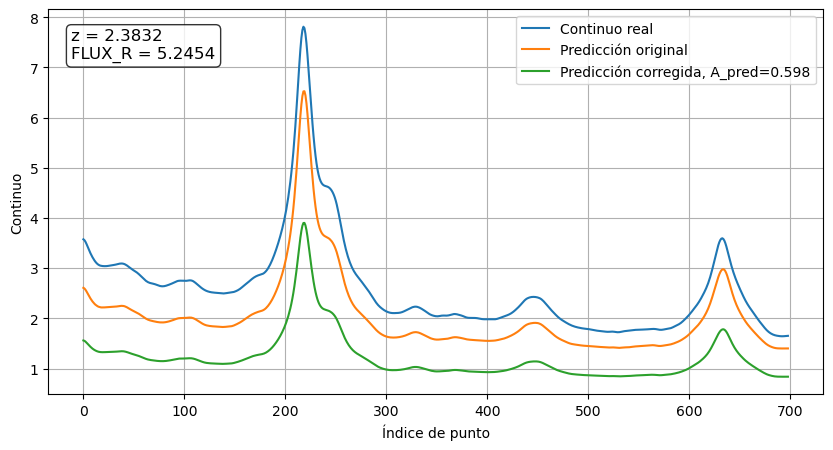

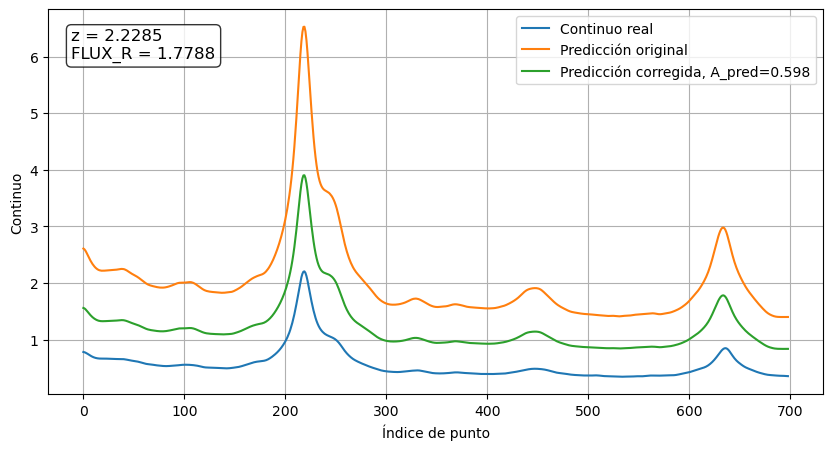

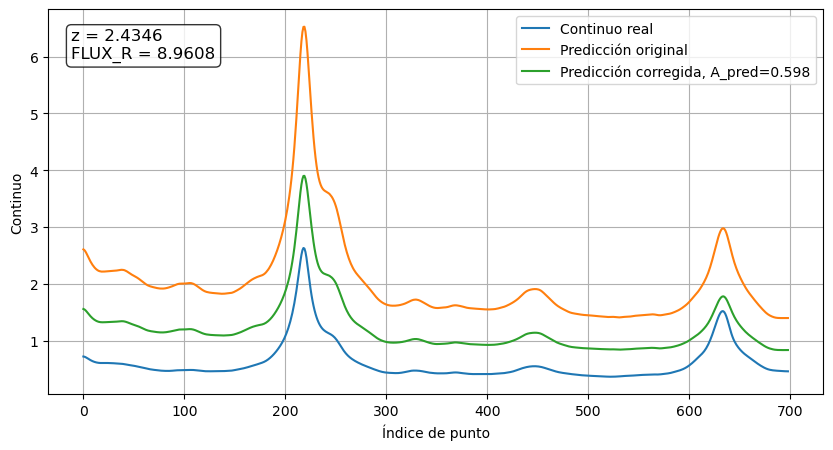

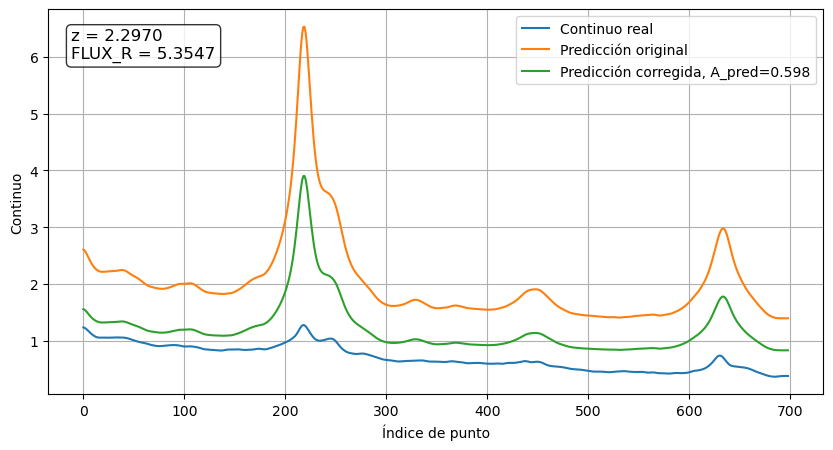

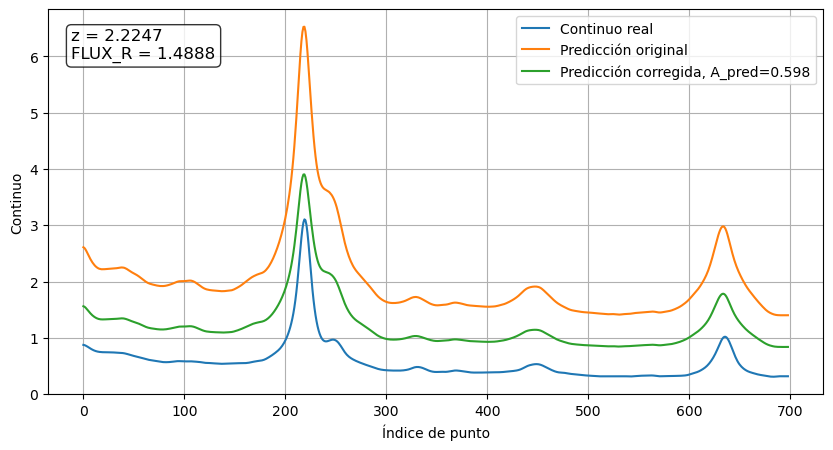

In [21]:
indices = [0, 10, 50, 100, 500]

for i in indices:
    z = X_val[i, 0]
    flux_r = X_val[i, 1]

    plt.figure(figsize=(10, 5))

    plt.plot(Y_val[i], label="Continuo real")
    plt.plot(Y_pred_val[i], label="Predicción original")
    plt.plot(Y_pred_val_corr[i], label=f"Predicción corregida, A_pred={A_pred_val[i]:.3f}")

    plt.xlabel("Índice de punto")
    plt.ylabel("Continuo")

    plt.text(
        0.03, 0.95,
        f"z = {z:.4f}\nFLUX_R = {flux_r:.4f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.legend()
    plt.grid()
    plt.show()

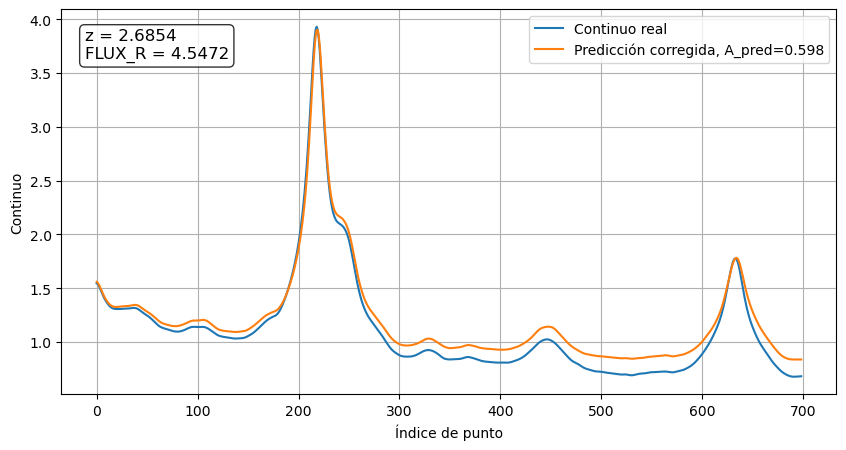

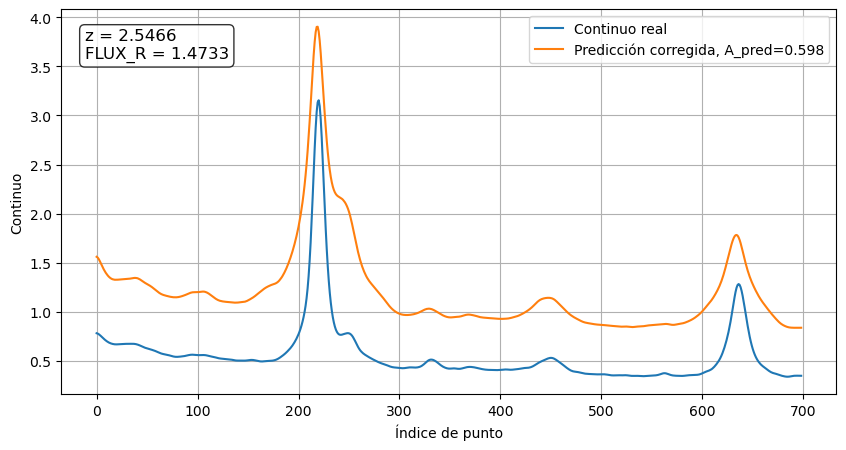

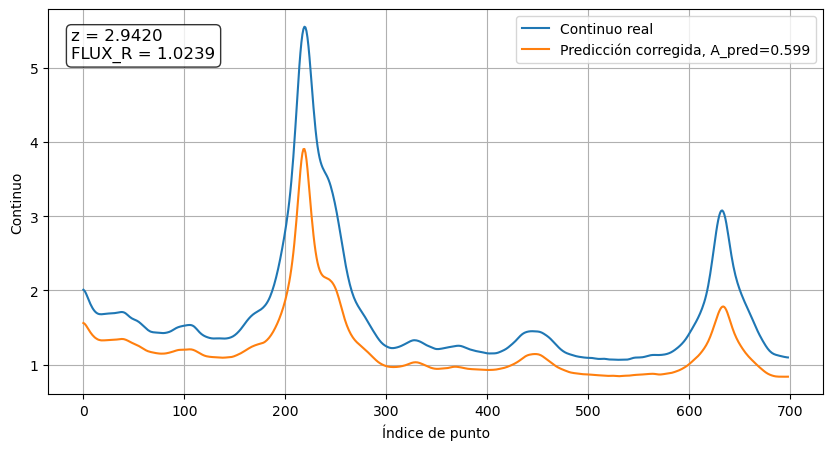

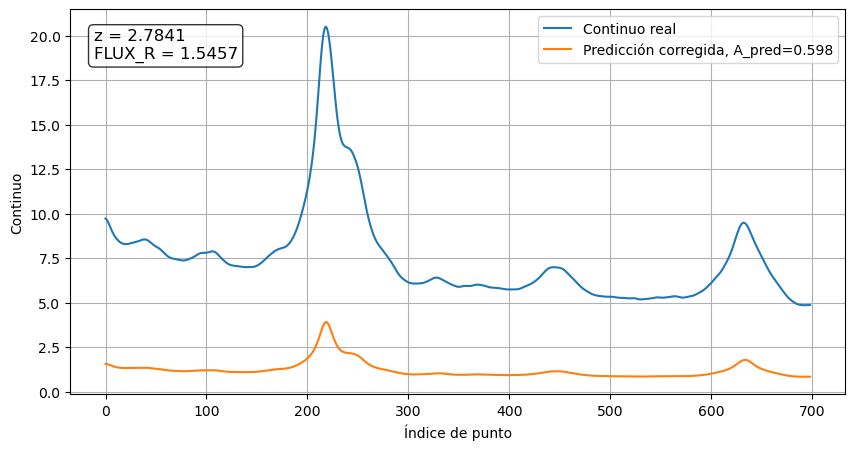

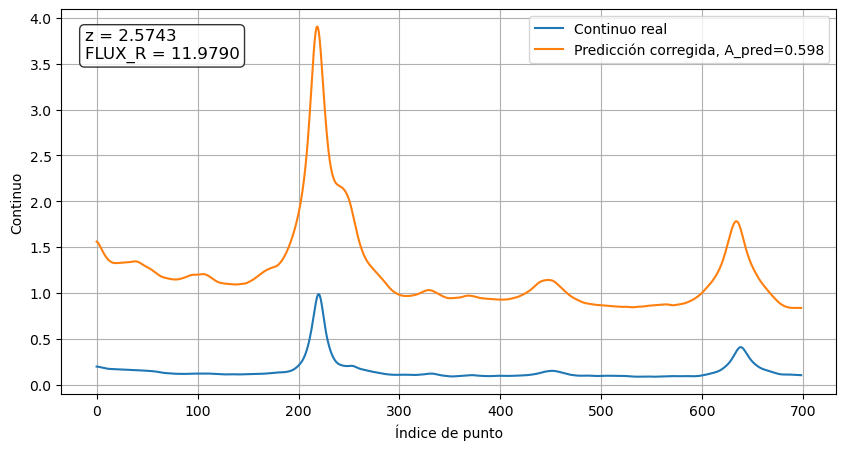

In [25]:
indices = [0, 10, 50, 100, 500]

for i in indices:
    z = X_test[i, 0]
    flux_r = X_test[i, 1]

    plt.figure(figsize=(10, 5))

    plt.plot(Y_test[i], label="Continuo real")
    #plt.plot(Y_pred_test[i], label="Predicción original")
    plt.plot(Y_pred_test_corr[i], label=f"Predicción corregida, A_pred={A_pred_test[i]:.3f}")

    plt.xlabel("Índice de punto")
    plt.ylabel("Continuo")

    plt.text(
        0.03, 0.95,
        f"z = {z:.4f}\nFLUX_R = {flux_r:.4f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )


    plt.legend()
    plt.grid()
    nombre_figura = f"figuras_continuo/continuo_corregido_indice_{i}_z_{z:.4f}.png"
    plt.savefig(nombre_figura, dpi=300, bbox_inches="tight")
    plt.show()